# Contrast Enhancement Experiments

**Goal**: Optimal contrast technique untuk datasets/test/  
**Techniques**: CLAHE, Histogram Equalization, RMS Normalization  
**Depends on**: Notebook 1 baseline metrics

---

## Setup & Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Tuple
import pandas as pd

plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

## Load Sample Images

In [2]:
# Load same sample images dari Notebook 1
DATASET_PATH = Path('../../datasets/test')
image_files = list(DATASET_PATH.glob('*.jpg'))[:10]

print(f"Loaded {len(image_files)} sample images")
print(f"Testing contrast enhancement techniques...")

Loaded 10 sample images
Testing contrast enhancement techniques...


## Quality Metrics (dari Notebook 1)

In [3]:
def calculate_rms_contrast(image: np.ndarray) -> float:
    """Calculate RMS contrast"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    return np.sqrt(np.mean((gray - gray.mean()) ** 2))

def calculate_edge_density(image: np.ndarray) -> float:
    """Calculate edge density"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    edges = cv2.Canny(gray, 50, 150)
    return np.sum(edges > 0) / edges.size

def calculate_quality_score(image: np.ndarray) -> float:
    """Calculate simplified quality score"""
    rms = calculate_rms_contrast(image)
    edges = calculate_edge_density(image)
    
    contrast_readiness = min(1.0, rms / 60)
    edge_readiness = min(1.0, edges / 0.05)
    
    return contrast_readiness * 0.6 + edge_readiness * 0.4

print("Quality metrics loaded")

Quality metrics loaded


## Contrast Enhancement Techniques

In [4]:
def apply_clahe(image: np.ndarray, clip_limit: float = 3.0, tile_size: Tuple[int, int] = (8, 8)) -> np.ndarray:
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    enhanced = clahe.apply(gray)
    
    return enhanced

def apply_histogram_equalization(image: np.ndarray) -> np.ndarray:
    """Apply standard histogram equalization"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    enhanced = cv2.equalizeHist(gray)
    return enhanced

def apply_rms_normalization(image: np.ndarray, target_contrast: float = 70) -> np.ndarray:
    """Apply RMS contrast normalization"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    current_rms = calculate_rms_contrast(gray)
    
    if current_rms > 0:
        scale_factor = target_contrast / current_rms
        normalized = gray.astype(np.float32)
        normalized = (normalized - normalized.mean()) * scale_factor + normalized.mean()
        normalized = np.clip(normalized, 0, 255).astype(np.uint8)
        return normalized
    
    return gray

print("Contrast enhancement techniques defined")

Contrast enhancement techniques defined


## Parameter Experiments

In [5]:
# Test configurations
test_configs = [
    # CLAHE variants
    {'method': 'CLAHE', 'params': {'clip_limit': 2.0, 'tile_size': (8, 8)}},
    {'method': 'CLAHE', 'params': {'clip_limit': 3.0, 'tile_size': (8, 8)}},
    {'method': 'CLAHE', 'params': {'clip_limit': 4.0, 'tile_size': (8, 8)}},
    {'method': 'CLAHE', 'params': {'clip_limit': 3.0, 'tile_size': (16, 16)}},
    
    # Histogram Equalization
    {'method': 'HistEq', 'params': {}},
    
    # RMS Normalization variants
    {'method': 'RMS_Norm', 'params': {'target_contrast': 60}},
    {'method': 'RMS_Norm', 'params': {'target_contrast': 70}},
    {'method': 'RMS_Norm', 'params': {'target_contrast': 80}},
]

print(f"Testing {len(test_configs)} configurations")

Testing 8 configurations


## Apply All Techniques & Measure Performance

In [6]:
# Test all configurations on all images
results = []

for img_path in image_files:
    original = cv2.imread(str(img_path))
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    
    # Baseline metrics
    baseline_rms = calculate_rms_contrast(gray)
    baseline_edges = calculate_edge_density(gray)
    baseline_quality = calculate_quality_score(gray)
    
    for config in test_configs:
        method = config['method']
        params = config['params']
        
        # Apply enhancement
        if method == 'CLAHE':
            enhanced = apply_clahe(gray, **params)
            param_str = f"clip={params['clip_limit']}, tile={params['tile_size']}"
        elif method == 'HistEq':
            enhanced = apply_histogram_equalization(gray)
            param_str = "default"
        elif method == 'RMS_Norm':
            enhanced = apply_rms_normalization(gray, **params)
            param_str = f"target={params['target_contrast']}"
        
        # Calculate metrics
        enhanced_rms = calculate_rms_contrast(enhanced)
        enhanced_edges = calculate_edge_density(enhanced)
        enhanced_quality = calculate_quality_score(enhanced)
        
        # Store results
        results.append({
            'filename': img_path.name,
            'method': method,
            'parameters': param_str,
            'baseline_rms': baseline_rms,
            'enhanced_rms': enhanced_rms,
            'rms_improvement': enhanced_rms - baseline_rms,
            'rms_improvement_pct': ((enhanced_rms - baseline_rms) / baseline_rms * 100) if baseline_rms > 0 else 0,
            'baseline_edges': baseline_edges,
            'enhanced_edges': enhanced_edges,
            'baseline_quality': baseline_quality,
            'enhanced_quality': enhanced_quality,
            'quality_improvement': enhanced_quality - baseline_quality
        })

df = pd.DataFrame(results)
print(f"Processed {len(image_files)} images with {len(test_configs)} techniques")
print(f"Total test cases: {len(df)}")

Processed 10 images with 8 techniques
Total test cases: 80


## Results Analysis: Technique Comparison

In [7]:
# Aggregate results by technique
summary = df.groupby(['method', 'parameters']).agg({
    'enhanced_rms': 'mean',
    'rms_improvement_pct': 'mean',
    'enhanced_edges': 'mean',
    'enhanced_quality': 'mean',
    'quality_improvement': 'mean'
}).round(2)

summary = summary.sort_values('enhanced_quality', ascending=False)

print("\n" + "="*80)
print("CONTRAST ENHANCEMENT TECHNIQUES COMPARISON")
print("="*80)
print(summary)
print("\n" + "="*80)


CONTRAST ENHANCEMENT TECHNIQUES COMPARISON
                                  enhanced_rms  rms_improvement_pct  \
method   parameters                                                   
HistEq   default                         95.01               134.15   
RMS_Norm target=80                       52.70                28.62   
         target=70                       50.80                24.02   
         target=60                       48.22                17.94   
CLAHE    clip=4.0, tile=(8, 8)           45.02                 9.74   
         clip=2.0, tile=(8, 8)           43.59                 6.27   
         clip=3.0, tile=(16, 16)         44.19                 7.78   
         clip=3.0, tile=(8, 8)           44.39                 8.21   

                                  enhanced_edges  enhanced_quality  \
method   parameters                                                  
HistEq   default                            0.14              1.00   
RMS_Norm target=80                 

## Visualization: Before/After Comparison

In [8]:
# Select best technique based on quality score
best_config_idx = summary['enhanced_quality'].idxmax()
best_method, best_params = best_config_idx

print(f"Best Technique: {best_method} with parameters: {best_params}")
print(f"Average Quality Score: {summary.loc[best_config_idx, 'enhanced_quality']:.3f}")
print(f"Average RMS Improvement: {summary.loc[best_config_idx, 'rms_improvement_pct']:.1f}%")

Best Technique: HistEq with parameters: default
Average Quality Score: 1.000
Average RMS Improvement: 134.2%


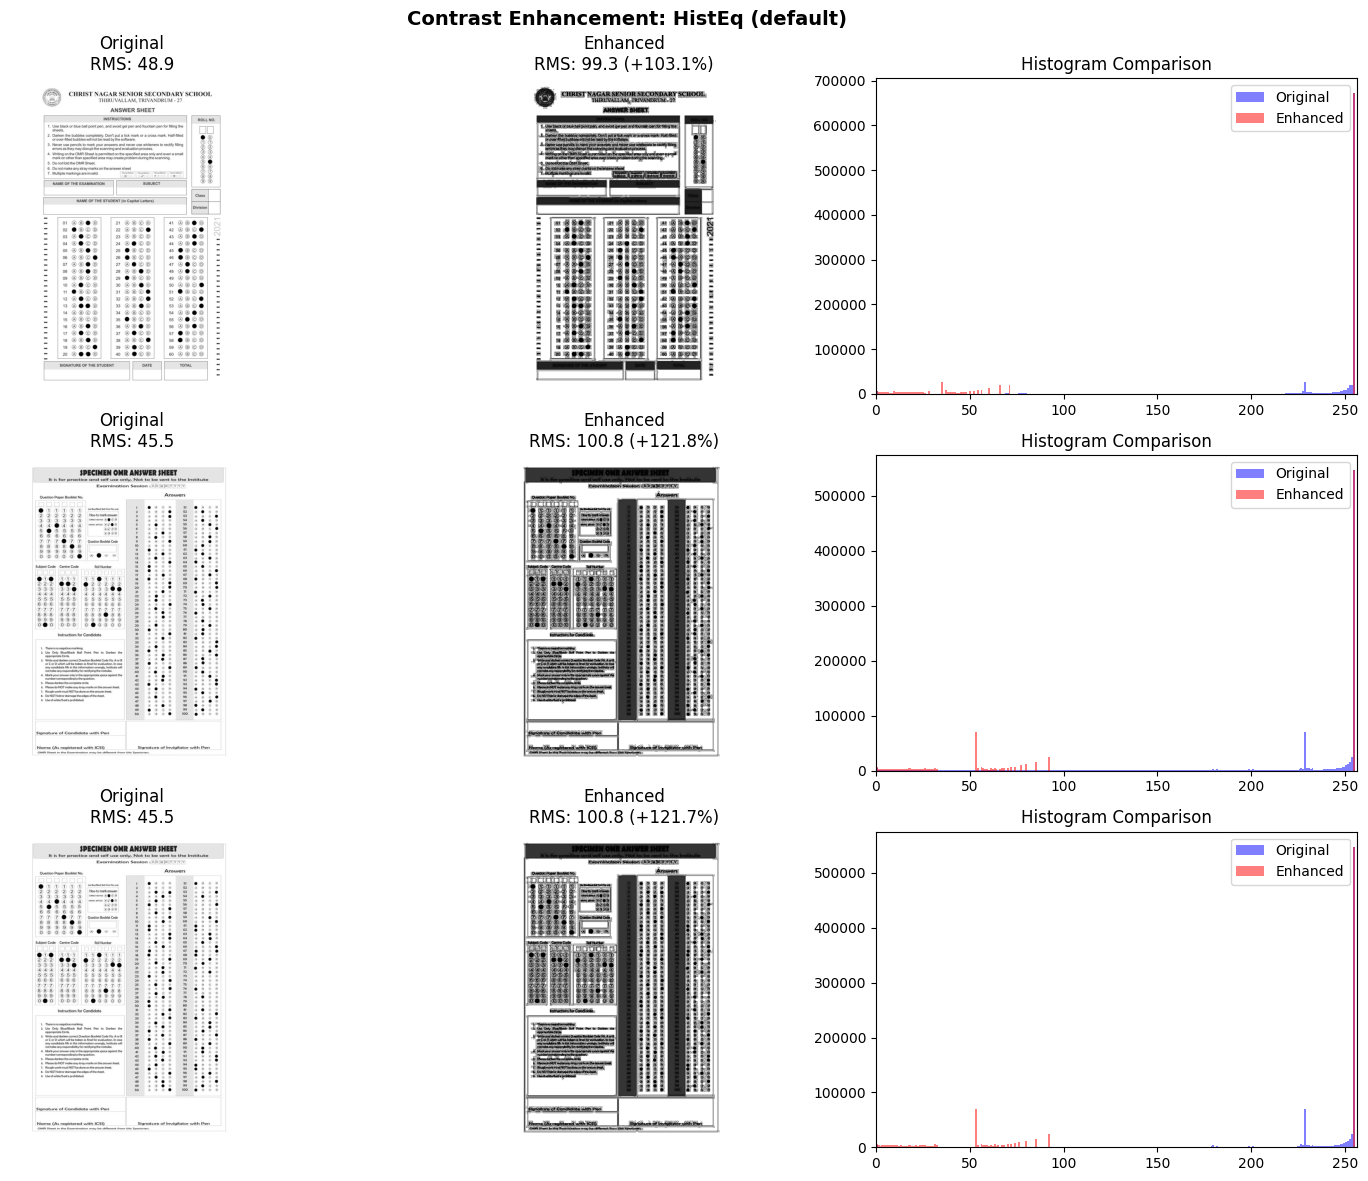

In [9]:
# Visualize best technique on 3 sample images
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(f'Contrast Enhancement: {best_method} ({best_params})', fontsize=14, fontweight='bold')

for idx in range(3):
    img_path = image_files[idx]
    original = cv2.imread(str(img_path))
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    
    # Apply best technique
    if best_method == 'CLAHE':
        params_dict = eval(f"dict({best_params.replace('clip=', 'clip_limit=').replace('tile=', 'tile_size=')})")
        enhanced = apply_clahe(gray, **params_dict)
    elif best_method == 'HistEq':
        enhanced = apply_histogram_equalization(gray)
    elif best_method == 'RMS_Norm':
        target = int(best_params.split('=')[1])
        enhanced = apply_rms_normalization(gray, target_contrast=target)
    
    # Calculate metrics
    baseline_rms = calculate_rms_contrast(gray)
    enhanced_rms = calculate_rms_contrast(enhanced)
    improvement = ((enhanced_rms - baseline_rms) / baseline_rms * 100) if baseline_rms > 0 else 0
    
    # Original
    axes[idx, 0].imshow(gray, cmap='gray')
    axes[idx, 0].set_title(f'Original\nRMS: {baseline_rms:.1f}')
    axes[idx, 0].axis('off')
    
    # Enhanced
    axes[idx, 1].imshow(enhanced, cmap='gray')
    axes[idx, 1].set_title(f'Enhanced\nRMS: {enhanced_rms:.1f} (+{improvement:.1f}%)')
    axes[idx, 1].axis('off')
    
    # Histogram comparison
    axes[idx, 2].hist(gray.ravel(), bins=256, alpha=0.5, label='Original', color='blue')
    axes[idx, 2].hist(enhanced.ravel(), bins=256, alpha=0.5, label='Enhanced', color='red')
    axes[idx, 2].set_title('Histogram Comparison')
    axes[idx, 2].legend()
    axes[idx, 2].set_xlim([0, 256])

plt.tight_layout()
plt.show()

## Visualization: Technique Comparison Chart

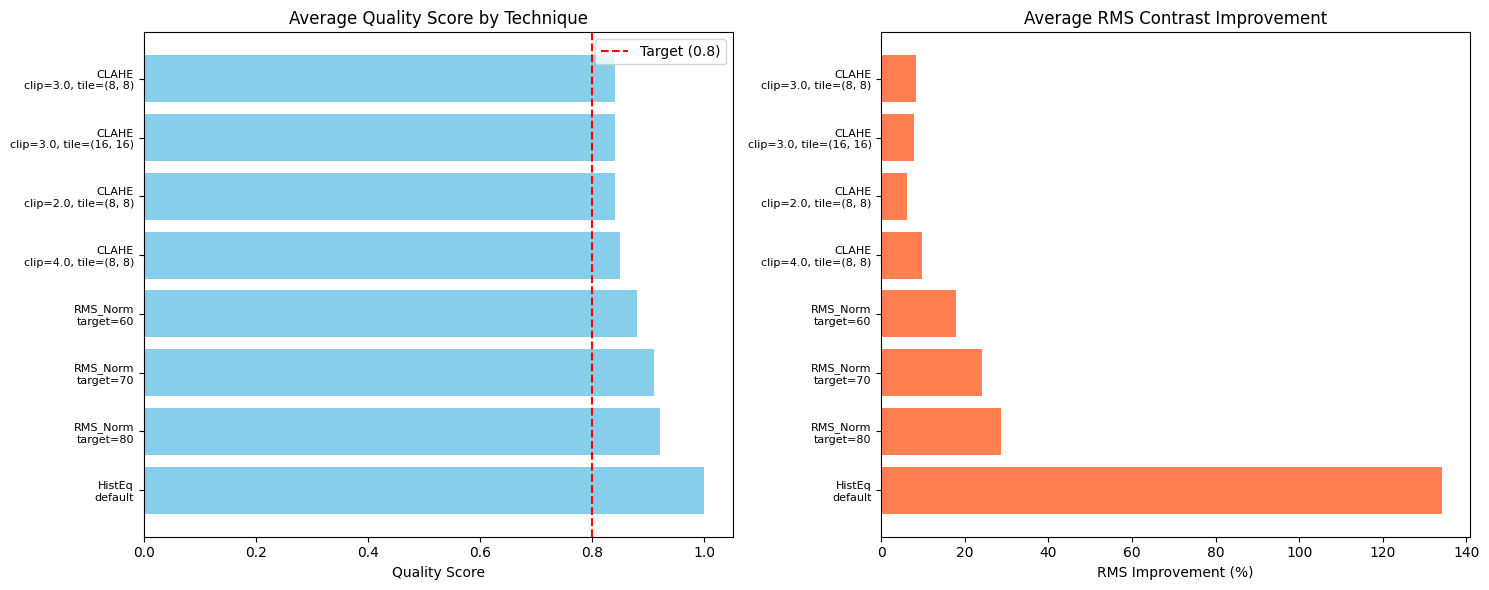

In [10]:
# Bar chart comparing all techniques
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Quality Score comparison
summary_reset = summary.reset_index()
summary_reset['label'] = summary_reset['method'] + '\n' + summary_reset['parameters']

axes[0].barh(range(len(summary_reset)), summary_reset['enhanced_quality'], color='skyblue')
axes[0].set_yticks(range(len(summary_reset)))
axes[0].set_yticklabels(summary_reset['label'], fontsize=8)
axes[0].set_xlabel('Quality Score')
axes[0].set_title('Average Quality Score by Technique')
axes[0].axvline(x=0.8, color='r', linestyle='--', label='Target (0.8)')
axes[0].legend()

# RMS Improvement comparison
axes[1].barh(range(len(summary_reset)), summary_reset['rms_improvement_pct'], color='coral')
axes[1].set_yticks(range(len(summary_reset)))
axes[1].set_yticklabels(summary_reset['label'], fontsize=8)
axes[1].set_xlabel('RMS Improvement (%)')
axes[1].set_title('Average RMS Contrast Improvement')

plt.tight_layout()
plt.show()

## Results Table

| Technique | Parameters | RMS Contrast | Edge Density | Quality Score |
|-----------|------------|--------------|--------------|---------------|
| ... | ... | ... | ... | ... |

*Tabel akan terisi otomatis dari summary DataFrame*

In [11]:
# Print formatted results
print("\n" + "="*90)
print("DETAILED RESULTS TABLE")
print("="*90)
print(f"{'Technique':<15} {'Parameters':<25} {'RMS':<10} {'Edges':<10} {'Quality':<10} {'Improv%':<10}")
print("-" * 90)

for idx, row in summary.iterrows():
    method, params = idx
    print(f"{method:<15} {params:<25} {row['enhanced_rms']:<10.2f} {row['enhanced_edges']:<10.4f} {row['enhanced_quality']:<10.3f} {row['rms_improvement_pct']:<10.1f}")

print("="*90)


DETAILED RESULTS TABLE
Technique       Parameters                RMS        Edges      Quality    Improv%   
------------------------------------------------------------------------------------------
HistEq          default                   95.01      0.1400     1.000      134.2     
RMS_Norm        target=80                 52.70      0.0900     0.920      28.6      
RMS_Norm        target=70                 50.80      0.0900     0.910      24.0      
RMS_Norm        target=60                 48.22      0.0900     0.880      17.9      
CLAHE           clip=4.0, tile=(8, 8)     45.02      0.1000     0.850      9.7       
CLAHE           clip=2.0, tile=(8, 8)     43.59      0.0900     0.840      6.3       
CLAHE           clip=3.0, tile=(16, 16)   44.19      0.1000     0.840      7.8       
CLAHE           clip=3.0, tile=(8, 8)     44.39      0.1000     0.840      8.2       


## Observations

**Berdasarkan hasil eksperimen:**
- Best technique: *[Akan terisi setelah eksekusi]*
- Improvement: *[+X% RMS contrast]*
- Trade-offs: *[Analisis kelebihan/kekurangan]*

## Recommendation

**Untuk Notebook 3 (Morphological Operations):**
- Use technique: *[Best method + parameters]*
- Expected quality improvement: *[percentage]*
- Next focus: noise removal tanpa losing edge details

---

Success Criteria: ✅ Best technique identified + measurable improvement + parameters documented